In [3]:
import pandas as pd
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import plotly.express as px

print("halo")

halo


FILTER DATA DAN BERSIHIN DATA

In [2]:
# 1. Baca data asli
df = pd.read_csv("AirBnb_data_case-study/listings.csv")

# 2. Tentukan kolom yang mau dipakai saja
keep_cols = [
    "id", "name", "neighbourhood_cleansed", "city", "state", "zipcode", 
    "latitude", "longitude",
    "property_type", "room_type", "accommodates", "bathrooms", "bedrooms", "beds",
    "price", "weekly_price", "monthly_price", "cleaning_fee", "extra_people",
    "minimum_nights", "maximum_nights", "availability_30", "availability_60",
    "availability_90", "availability_365",
    "number_of_reviews", "review_scores_rating", "reviews_per_month",
    "host_id", "host_since", "host_is_superhost", "host_listings_count"
]

# 3. Filter hanya kolom tersebut
df_clean = df[keep_cols]

# 4. Simpan jadi file CSV baru
df_clean.to_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv", index=False)

print("CSV baru berhasil dibuat dengan", df_clean.shape[1], "kolom.")

CSV baru berhasil dibuat dengan 32 kolom.


In [3]:
df_filtered = df[df["availability_30"] < 30]

# Kalau kamu mau pakai periode lain, tinggal ganti:
# df_filtered = df[df["availability_60"] < 60]
# df_filtered = df[df["availability_90"] < 90]
# df_filtered = df[df["availability_365"] < 365]

# Timpa file
df_filtered.to_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv", index=False)

print("Data akhir:", df.shape[0], "→", df_filtered.shape[0], "rows")

Data akhir: 3585 → 3396 rows


In [4]:
# Kalau kamu mau pakai periode lain, tinggal ganti:
df_filtered = df[df["availability_60"] < 60]
# df_filtered = df[df["availability_90"] < 90]
# df_filtered = df[df["availability_365"] < 365]

# Timpa file
df_filtered.to_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv", index=False)

print("Data akhir:", df.shape[0], "→", df_filtered.shape[0], "rows")

Data akhir: 3585 → 3414 rows


In [5]:
# Kalau kamu mau pakai periode lain, tinggal ganti:
df_filtered = df[df["availability_90"] < 90]
# df_filtered = df[df["availability_365"] < 365]

# Timpa file
df_filtered.to_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv", index=False)

print("Data akhir:", df.shape[0], "→", df_filtered.shape[0], "rows")

Data akhir: 3585 → 3428 rows


In [6]:
# Kalau kamu mau pakai periode lain, tinggal ganti:
df_filtered = df[df["availability_365"] < 365]

# Timpa file
df_filtered.to_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv", index=False)

print("Data akhir:", df.shape[0], "→", df_filtered.shape[0], "rows")

Data akhir: 3585 → 3482 rows


In [8]:
df = pd.read_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv")
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("[$,]", "", regex=True)   # buang simbol
    .astype(float)
)

df.groupby(["price", "id"]).size().reset_index(name="count")

,price,id,count
0,10.0,13926201,1
1,11.0,12736032,1
2,20.0,14867747,1
3,22.0,14300751,1
4,22.0,14428514,1
...,...,...,...
3477,1345.0,14798673,1
3478,1372.0,6451456,1
3479,1400.0,6093430,1
3480,3000.0,12679021,1


In [4]:
df = pd.read_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv")
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("[$,]", "", regex=True)   # buang simbol
    .astype(float)
)
df.groupby(["weekly_price", "id"]).size().reset_index(name="count")

,weekly_price,id,count
0,"$1,000.00",23619,1
1,"$1,000.00",169938,1
2,"$1,000.00",220676,1
3,"$1,000.00",336946,1
4,"$1,000.00",1090413,1
...,...,...,...
860,$999.00,4559774,1
861,$999.00,8428314,1
862,$999.00,8556025,1
863,$999.00,13521992,1


In [6]:
df = pd.read_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv")
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("[$,]", "", regex=True)   # buang simbol
    .astype(float)
)
df.groupby(["monthly_price", "id"]).size().reset_index(name="count")

,monthly_price,id,count
0,"$1,000.00",890705,1
1,"$1,000.00",1173306,1
2,"$1,000.00",3968797,1
3,"$1,000.00",4032126,1
4,"$1,000.00",4598026,1
...,...,...,...
853,$950.00,7086825,1
854,$950.00,7252607,1
855,$950.00,8899828,1
856,$950.00,9494511,1


In [7]:
# 2. Pastikan kolom availability jadi numerik
availability_periods = [30, 60, 90, 365]
for P in availability_periods:
    col_av = f"availability_{P}"
    if col_av in df.columns:
        df[col_av] = pd.to_numeric(df[col_av], errors="coerce")
        
        # 3. Tambah kolom baru days_occupied
        col_occ = f"days_occupied_{P}"
        df[col_occ] = (P - df[col_av]).clip(lower=0).fillna(0).astype(int)

# 4. Simpan ke file baru
df.to_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv", index=False)

# (Opsional) cek kolom baru
print(df[["availability_30","days_occupied_30"]].head())

print("✅ File sudah tersalin ke AirBnb_data_case-study/Best_Property/listings_clean.csv")

   availability_30  days_occupied_30
0                0                30
1               26                 4
2               19                11
3                6                24
4               13                17
✅ File sudah tersalin ke AirBnb_data_case-study/Best_Property/listings_clean.csv


In [8]:
check_new_column = [30, 60, 90, 365]

for L in check_new_column:
    print(df[[f"availability_{L}",f"days_occupied_{L}"]].head())

   availability_30  days_occupied_30
0                0                30
1               26                 4
2               19                11
3                6                24
4               13                17
   availability_60  days_occupied_60
0                0                60
1               54                 6
2               46                14
3               16                44
4               34                26
   availability_90  days_occupied_90
0                0                90
1               84                 6
2               61                29
3               26                64
4               59                31
   availability_365  days_occupied_365
0                 0                365
1               359                  6
2               319                 46
3                98                267
4               334                 31


In [9]:
df["price"] = (
    df["price"].astype(str)
    .str.replace("[$,]", "", regex=True)
    .str.strip()
    .astype(float)
)

periods = [30, 60, 90, 365]
for i in periods:
    kolom_baru = f"total_revenue_{i}"
    # ambil kolom days_occupied_i dan kalikan dengan price
    df[kolom_baru] = (df[f"days_occupied_{i}"] * df["price"]).clip(lower=0).fillna(0).astype(int)

# Simpan ke file baru
df.to_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv", index=False)
print("✅ File dengan kolom revenue tersimpan")

✅ File dengan kolom revenue tersimpan


In [12]:
# Unik value (daftar tipe kamar yang ada)
print(df["room_type"].unique())

# Hitung jumlah masing-masing room_type
print(df["room_type"].value_counts())

df["total_revenue_all"] = (
    df["total_revenue_30"] +
    df["total_revenue_60"] +
    df["total_revenue_90"] +
    df["total_revenue_365"]
)

# Simpan ke file baru
df.to_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv", index=False)
print("✅ File dengan kolom revenue tersimpan")

['Entire home/apt' 'Private room' 'Shared room']
room_type
Entire home/apt    2088
Private room       1324
Shared room          70
Name: count, dtype: int64
✅ File dengan kolom revenue tersimpan


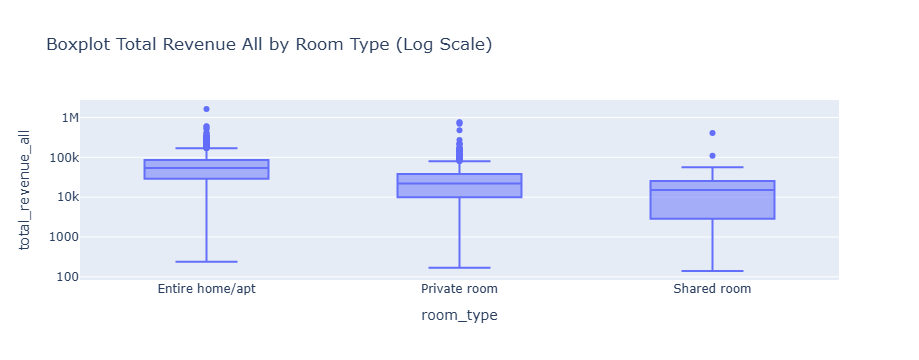

In [22]:
# boxplot dengan plotly
fig = px.box(
    df,
    x="room_type",
    y="total_revenue_all",
    title="Boxplot Total Revenue All by Room Type (Log Scale)",
    log_y=True   # <--- aktifkan log scale
)
fig.show()

In [23]:
summary = df.groupby("room_type")["total_revenue_all"].describe()
print(summary)

                  count          mean           std    min      25%      50%  \
room_type                                                                      
Entire home/apt  2088.0  65400.108238  64929.612799  238.0  29088.5  54278.5   
Private room     1324.0  30351.711480  45368.091278  168.0   9895.0  22170.0   
Shared room        70.0  23616.157143  50198.105505  140.0   2886.0  15151.5   

                      75%        max  
room_type                             
Entire home/apt  85412.25  1635000.0  
Private room     38150.00   763000.0  
Shared room      25172.25   408750.0  


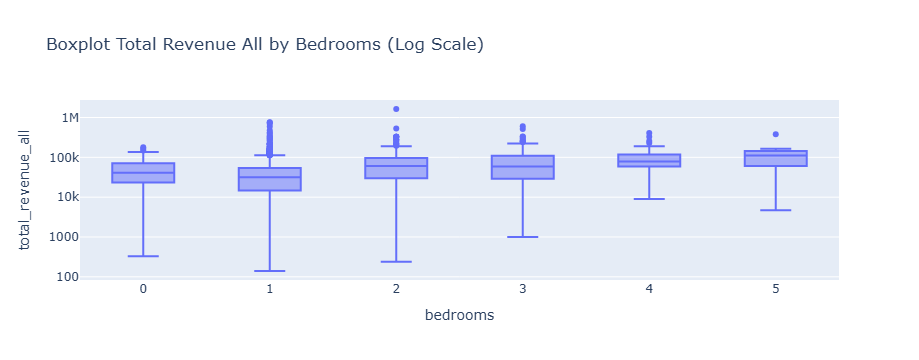

           count           mean           std     min      25%       50%  \
bedrooms                                                                   
0.0        281.0   48271.241993  31865.042304   330.0  23364.0   40755.0   
1.0       2300.0   41997.623478  49037.977203   140.0  14668.5   31500.0   
2.0        677.0   72114.161004  81902.550535   238.0  30080.0   60291.0   
3.0        153.0   84210.045752  87729.184815   996.0  29000.0   58740.0   
4.0         45.0   99822.422222  78481.312728  9000.0  59500.0   78300.0   
5.0         16.0  114348.687500  87323.293874  4680.0  63500.0  110747.5   

                75%        max  
bedrooms                        
0.0        71208.00   179305.0  
1.0        53991.25   763000.0  
2.0        95918.00  1635000.0  
3.0       109000.00   603750.0  
4.0       117750.00   408750.0  
5.0       142766.25   382050.0  


In [26]:
# boxplot dengan plotly
fig = px.box(
    df,
    x="bedrooms",
    y="total_revenue_all",
    title="Boxplot Total Revenue All by Bedrooms (Log Scale)",
    log_y=True   # <--- aktifkan log scale
)
fig.show()

summary = df.groupby("bedrooms")["total_revenue_all"].describe()
print(summary)

# THIS CODE IS FOR SEACHING BEST PROPERTY AND THINGS YOU SHOULD BUY IF YOU HAVE BUSSINESS YOU CAN ADD MORE VARIABLE INTO THIS

# THE BEST BY REVENUE IS 5 BEDROOM AND ENTIRE HOME/APT